# Stage 24 — Exp A Analysis: Attention-Weighted Prototype Loss

Analyses `proto_seg_ct_l1234_attn_wloss.pth` and compares against the four v5 models.

**RQ6:** Does weighting prototype losses by attention weight eliminate gradient
contamination and recover L4 prototype quality (purity, AP), while preserving
the level hierarchy discovery?

Success criteria:
- Purity L4 > 0.70  (vs 0.537 in M4-attn noent)
- AP L4 > 0.15      (vs 0.085)
- 3D Dice ≥ 0.8416  (must not regress) — already confirmed: 0.8475 ✅
- w_L4 > 0.5, w_L1 + w_L2 < 0.10

## 1. Imports & Config

In [2]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import pathlib

from src.data.mmwhs_dataset import (
    make_dataloaders,
    LABEL_NAMES,
    NUM_CLASSES,
    MMWHSPatientDataset,
    MMWHSSliceDataset,
)
from src.models.proto_seg_net import ProtoSegNet
from src.metrics.proto_quality import (
    compute_purity,
    compute_compactness,
    compute_level_dominance,
    compute_per_level_ap,
)
from src.metrics.dice import dice_per_class, mean_foreground_dice

MODALITY = "ct"
DATA_DIR = "data/pack/processed_data"
OUT = "results/v6/proto_quality/m4_attn_wloss"
pathlib.Path(OUT).mkdir(parents=True, exist_ok=True)

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]
LEVEL_COLORS = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
print(f"Device: {DEVICE}")

Device: mps


## 2. Load Models

In [3]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=16)


def load_model(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    levels = ckpt.get("proto_levels") or [1, 2, 3, 4]
    m = ProtoSegNet(
        n_classes=NUM_CLASSES,
        proto_levels=levels,
        use_level_attention=ckpt.get("use_level_attention", False),
    ).to(DEVICE)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    tag = (
        f"wloss={ckpt.get('weighted_proto_loss', False)}"
        if ckpt.get("use_level_attention")
        else ""
    )
    print(
        f"{path.split('/')[-1]:<52}  levels={levels}  "
        f"attn={ckpt.get('use_level_attention', False)}  "
        f"best_val={ckpt.get('best_val_dice', 0):.4f}  {tag}"
    )
    return m


m4 = load_model("checkpoints/proto_seg_ct_l2.pth")  # M4 (max)
m4_attn = load_model("checkpoints/proto_seg_ct_l1234_attn.pth")  # M4-attn λ=0.02
m4_noent = load_model("checkpoints/proto_seg_ct_l1234_attn_noent.pth")  # M4-attn λ=0
m4_wloss = load_model("checkpoints/proto_seg_ct_l1234_attn_wloss.pth")  # Exp A ← new
m2 = load_model("checkpoints/proto_seg_ct_l3l4.pth")  # M2 (max)

proto_seg_ct_l2.pth                                   levels=[1, 2, 3, 4]  attn=False  best_val=0.8173  
proto_seg_ct_l1234_attn.pth                           levels=[1, 2, 3, 4]  attn=True  best_val=0.7711  wloss=False
proto_seg_ct_l1234_attn_noent.pth                     levels=[1, 2, 3, 4]  attn=True  best_val=0.7949  wloss=False
proto_seg_ct_l1234_attn_wloss.pth                     levels=[1, 2, 3, 4]  attn=True  best_val=0.8203  wloss=True
proto_seg_ct_l3l4.pth                                 levels=[3, 4]  attn=False  best_val=0.8380  


## 3. 3D Dice Evaluation

In [4]:
@torch.no_grad()
def eval_3d(model, label):
    ds = MMWHSPatientDataset(DATA_DIR, MODALITY, "test")
    all_means, per_class = [], {n: [] for n in FG_NAMES}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si : si + 1])[0].cpu() for si in range(imgs.shape[0])]
        d = dice_per_class(torch.cat(logits_all), s["label"])
        all_means.append(mean_foreground_dice(d))
        for n in FG_NAMES:
            per_class[n].append(d.get(n, float("nan")))
    mean_fg = float(np.mean(all_means))
    pc = {n: float(np.mean(v)) for n, v in per_class.items()}
    print(f"[{label:<22}]  3D Dice = {mean_fg:.4f}")
    return mean_fg, pc


dice_m4, pc_m4 = eval_3d(m4, "M4 (max)")
dice_m4_attn, pc_m4_attn = eval_3d(m4_attn, "M4-attn λ=0.02")
dice_m4_noent, pc_m4_noent = eval_3d(m4_noent, "M4-attn λ=0 noent")
dice_m4_wloss, pc_m4_wloss = eval_3d(m4_wloss, "M4-attn wloss")
dice_m2, pc_m2 = eval_3d(m2, "M2 (max)")

print(f"\nM4-attn-wloss vs M4-attn-noent : {dice_m4_wloss - dice_m4_noent:+.4f}")
print(f"M4-attn-wloss vs M4            : {dice_m4_wloss - dice_m4:+.4f}")
print(f"M4-attn-wloss vs M2            : {dice_m4_wloss - dice_m2:+.4f}")

[M4 (max)              ]  3D Dice = 0.8407
[M4-attn λ=0.02        ]  3D Dice = 0.7861
[M4-attn λ=0 noent     ]  3D Dice = 0.8416
[M4-attn wloss         ]  3D Dice = 0.8475
[M2 (max)              ]  3D Dice = 0.8722

M4-attn-wloss vs M4-attn-noent : +0.0059
M4-attn-wloss vs M4            : +0.0068
M4-attn-wloss vs M2            : -0.0248


## 4. Proto Quality Metrics — M4-attn-wloss

In [5]:
print("Computing purity…")
purity_wloss = compute_purity(m4_wloss, loaders["train"])
purity_wloss.to_csv(f"{OUT}/purity_summary.csv", index=False)

print("Computing compactness…")
comp_wloss = compute_compactness(m4_wloss, loaders["test"])
comp_wloss.to_csv(f"{OUT}/compactness.csv", index=False)

print("Computing level dominance…")
dom_wloss = compute_level_dominance(m4_wloss, loaders["test"])
dom_wloss.to_csv(f"{OUT}/level_dominance.csv", index=False)

print("Computing per-level AP…")
ap_wloss = compute_per_level_ap(m4_wloss, loaders["test"])
ap_wloss.to_csv(f"{OUT}/per_level_ap.csv", index=False)

print("Done.")
pur_l4_wloss = purity_wloss[purity_wloss["level"] == 4]["purity"].mean()
ap_l4_wloss = ap_wloss[ap_wloss["level"] == 4]["ap"].mean()
comp_l4_wloss = comp_wloss[comp_wloss["level"] == 4]["compactness"].mean()
dom_l4_wloss = dom_wloss.iloc[0].get("frac_l4", 0)

print(f"  Purity L4     : {pur_l4_wloss:.3f}   (target > 0.70)")
print(f"  AP L4         : {ap_l4_wloss:.3f}   (target > 0.15)")
print(f"  Compactness L4: {comp_l4_wloss:.3f}")
print(f"  Dominance L4  : {dom_l4_wloss * 100:.1f}%")

Computing purity…
Computing compactness…
Computing level dominance…
Computing per-level AP…
Done.
  Purity L4     : 0.697   (target > 0.70)
  AP L4         : 0.195   (target > 0.15)
  Compactness L4: 0.365
  Dominance L4  : 17.5%


## 5. Five-Model Comparison Table

In [7]:
def load_metric(csv_path, level_col="level", val_col="purity", level=4):
    df = pd.read_csv(csv_path)

    alias_map = {
        "purity": ["purity", "purity_mean", "mean_purity", "score", "value"],
        "ap": ["ap", "AP", "avg_precision", "average_precision", "score", "value"],
        "compactness": [
            "compactness",
            "compactness_mean",
            "mean_compactness",
            "score",
            "value",
        ],
    }

    candidates = alias_map.get(val_col, [val_col])
    metric_col = next((c for c in candidates if c in df.columns), None)

    if metric_col is None:
        numeric_cols = [
            c
            for c in df.columns
            if c != level_col and pd.api.types.is_numeric_dtype(df[c])
        ]
        if not numeric_cols:
            raise ValueError(
                f"No numeric metric column found in {csv_path}. "
                f"Columns: {list(df.columns)}"
            )
        metric_col = numeric_cols[0]

    if level_col in df.columns:
        level_df = df[df[level_col] == level]
        if level_df.empty:
            level_df = df
    else:
        level_df = df

    return float(level_df[metric_col].mean())


def load_dom(csv_path):
    return pd.read_csv(csv_path).iloc[0].get("frac_l4", 0)


# Load pre-computed v4/v5 results
m4_pur = load_metric("results/v4/proto_quality/v1/purity_summary.csv", val_col="purity")
m4_ap = load_metric("results/v4/proto_quality/v1/per_level_ap.csv", val_col="ap")
m4_comp = load_metric(
    "results/v4/proto_quality/v1/compactness.csv", val_col="compactness"
)
m4_dom = load_dom("results/v4/proto_quality/v1/level_dominance.csv")

attn_pur = load_metric(
    "results/v5/proto_quality/m4_attn/purity_summary.csv", val_col="purity"
)
attn_ap = load_metric("results/v5/proto_quality/m4_attn/per_level_ap.csv", val_col="ap")
attn_comp = load_metric(
    "results/v5/proto_quality/m4_attn/compactness.csv", val_col="compactness"
)
attn_dom = load_dom("results/v5/proto_quality/m4_attn/level_dominance.csv")

noent_pur = load_metric(
    "results/v5/proto_quality/m4_attn_noent/purity_summary.csv", val_col="purity"
)
noent_ap = load_metric(
    "results/v5/proto_quality/m4_attn_noent/per_level_ap.csv", val_col="ap"
)
noent_comp = load_metric(
    "results/v5/proto_quality/m4_attn_noent/compactness.csv", val_col="compactness"
)
noent_dom = load_dom("results/v5/proto_quality/m4_attn_noent/level_dominance.csv")

m2_pur = load_metric(
    "results/v4/proto_quality/m2_l3l4/purity_summary.csv", val_col="purity"
)
m2_ap = load_metric("results/v4/proto_quality/m2_l3l4/per_level_ap.csv", val_col="ap")
m2_comp = load_metric(
    "results/v4/proto_quality/m2_l3l4/compactness.csv", val_col="compactness"
)
m2_dom = load_dom("results/v4/proto_quality/m2_l3l4/level_dominance.csv")

rows = {
    "Model": ["M4 (max)", "M4-attn λ=0.02", "M4-attn λ=0", "M4-attn wloss", "M2 (max)"],
    "Aggregation": ["max", "uniform avg", "learned", "learned+wloss", "max"],
    "3D Dice": [
        f"{dice_m4:.4f}",
        f"{dice_m4_attn:.4f}",
        f"{dice_m4_noent:.4f}",
        f"{dice_m4_wloss:.4f}",
        f"{dice_m2:.4f}",
    ],
    "Purity L4": [
        f"{m4_pur:.3f}",
        f"{attn_pur:.3f}",
        f"{noent_pur:.3f}",
        f"{pur_l4_wloss:.3f}",
        f"{m2_pur:.3f}",
    ],
    "Compact. L4": [
        f"{m4_comp:.3f}",
        f"{attn_comp:.3f}",
        f"{noent_comp:.3f}",
        f"{comp_l4_wloss:.3f}",
        f"{m2_comp:.3f}",
    ],
    "AP L4": [
        f"{m4_ap:.3f}",
        f"{attn_ap:.3f}",
        f"{noent_ap:.3f}",
        f"{ap_l4_wloss:.3f}",
        f"{m2_ap:.3f}",
    ],
    "Dom. L4": [
        f"{m4_dom * 100:.1f}%",
        f"{attn_dom * 100:.1f}%",
        f"{noent_dom * 100:.1f}%",
        f"{dom_l4_wloss * 100:.1f}%",
        f"{m2_dom * 100:.1f}%",
    ],
}
df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
df_cmp.to_csv("results/v6/comparison_table_v6_expA.csv", index=False)

         Model   Aggregation 3D Dice Purity L4 Compact. L4 AP L4 Dom. L4
      M4 (max)           max  0.8407     0.824       0.573 0.189    4.3%
M4-attn λ=0.02   uniform avg  0.7861     0.526       0.575 0.187    9.7%
   M4-attn λ=0       learned  0.8416     0.537       0.494 0.085   12.5%
 M4-attn wloss learned+wloss  0.8475     0.697       0.365 0.195   17.5%
      M2 (max)           max  0.8722     0.804       0.361 0.236   49.1%


## 6. Purity by Level: noent vs wloss

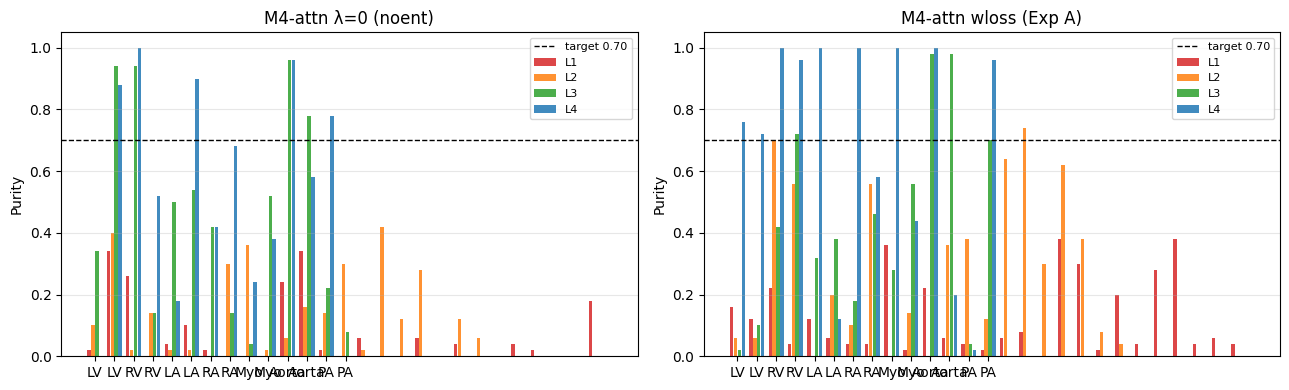

Mean purity by level:
Level       noent    wloss        Δ
L1          0.064    0.121   +0.058
L2          0.146    0.288   +0.142
L3          0.469    0.439   -0.030
L4          0.537    0.697   +0.160


In [9]:
purity_noent = pd.read_csv("results/v5/proto_quality/m4_attn_noent/purity_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, title in zip(
    axes, [purity_noent, purity_wloss], ["M4-attn λ=0 (noent)", "M4-attn wloss (Exp A)"]
):
    for i, l in enumerate([1, 2, 3, 4]):
        sub = df[df["level"] == l]
        if sub.empty:
            continue
        if "class_name" in sub.columns:
            classes = sub["class_name"].astype(str).tolist()
        elif "class_idx" in sub.columns:
            classes = [LABEL_NAMES.get(int(c), str(c)) for c in sub["class_idx"].values]
        elif "class" in sub.columns:
            classes = [LABEL_NAMES.get(int(c), str(c)) for c in sub["class"].values]
        else:
            classes = [f"proto_{j}" for j in range(len(sub))]
        vals = sub["purity"].values
        x = np.arange(len(classes))
        ax.bar(
            x + i * 0.2 - 0.3,
            vals,
            0.18,
            label=f"L{l}",
            color=LEVEL_COLORS[i],
            alpha=0.85,
        )
    ax.axhline(0.70, color="black", ls="--", lw=1, label="target 0.70")
    ax.set_xticks(np.arange(len(classes)))
    ax.set_xticklabels(classes)
    ax.set_ylabel("Purity")
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT}/purity_by_level_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Numeric summary by level
print("Mean purity by level:")
print(f"{'Level':<8} {'noent':>8} {'wloss':>8} {'Δ':>8}")
for l in [1, 2, 3, 4]:
    noent_p = (
        purity_noent[purity_noent["level"] == l]["purity"].mean()
        if not purity_noent[purity_noent["level"] == l].empty
        else float("nan")
    )
    wloss_p = (
        purity_wloss[purity_wloss["level"] == l]["purity"].mean()
        if not purity_wloss[purity_wloss["level"] == l].empty
        else float("nan")
    )
    print(f"L{l:<7} {noent_p:>8.3f} {wloss_p:>8.3f} {wloss_p - noent_p:>+8.3f}")

## 7. AP by Level: noent vs wloss

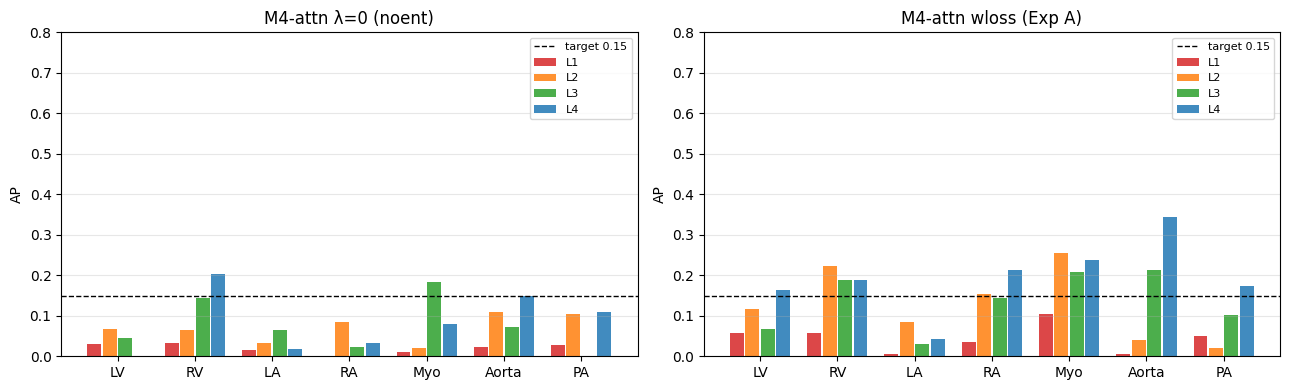

Mean AP by level:
Level       noent    wloss        Δ
L1          0.020    0.045   +0.025
L2          0.069    0.128   +0.059
L3          0.076    0.136   +0.060
L4          0.085    0.195   +0.110


In [11]:
ap_noent = pd.read_csv("results/v5/proto_quality/m4_attn_noent/per_level_ap.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, title in zip(
    axes, [ap_noent, ap_wloss], ["M4-attn λ=0 (noent)", "M4-attn wloss (Exp A)"]
):
    for i, l in enumerate([1, 2, 3, 4]):
        sub = df[df["level"] == l]
        if sub.empty:
            continue
        if "class_name" in sub.columns:
            classes = sub["class_name"].astype(str).tolist()
        elif "class_idx" in sub.columns:
            classes = [LABEL_NAMES.get(int(c), str(c)) for c in sub["class_idx"].values]
        elif "class" in sub.columns:
            classes = [LABEL_NAMES.get(int(c), str(c)) for c in sub["class"].values]
        else:
            classes = [f"proto_{j}" for j in range(len(sub))]
        ax.bar(
            np.arange(len(classes)) + i * 0.2 - 0.3,
            sub["ap"].values,
            0.18,
            label=f"L{l}",
            color=LEVEL_COLORS[i],
            alpha=0.85,
        )
    ax.axhline(0.15, color="black", ls="--", lw=1, label="target 0.15")
    ax.set_xticks(np.arange(len(classes)))
    ax.set_xticklabels(classes)
    ax.set_ylabel("AP")
    ax.set_ylim(0, 0.8)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT}/ap_by_level_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean AP by level:")
print(f"{'Level':<8} {'noent':>8} {'wloss':>8} {'Δ':>8}")
for l in [1, 2, 3, 4]:
    noent_a = (
        ap_noent[ap_noent["level"] == l]["ap"].mean()
        if not ap_noent[ap_noent["level"] == l].empty
        else float("nan")
    )
    wloss_a = (
        ap_wloss[ap_wloss["level"] == l]["ap"].mean()
        if not ap_wloss[ap_wloss["level"] == l].empty
        else float("nan")
    )
    print(f"L{l:<7} {noent_a:>8.3f} {wloss_a:>8.3f} {wloss_a - noent_a:>+8.3f}")

## 8. Attention Weight Evolution: noent vs wloss

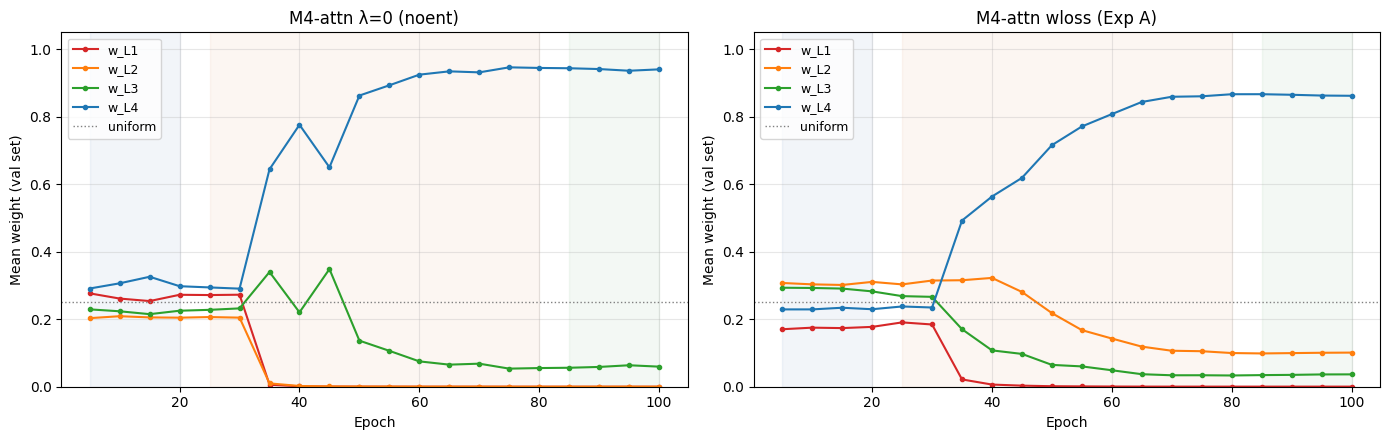

noent   ep100: L1=0.0000  L2=0.0001  L3=0.0595  L4=0.9403
wloss   ep100: L1=0.0003  L2=0.1011  L3=0.0366  L4=0.8620


In [12]:
attn_noent_log = pd.read_csv(
    "results/v5/attention_weight_evolution_l1234_attn_noent.csv"
)
attn_wloss_log = pd.read_csv(
    "results/v6/attention_weight_evolution_l1234_attn_wloss.csv"
)

PHASE_COLORS = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}
PROTO_LEVELS = [1, 2, 3, 4]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
titles = ["M4-attn λ=0 (noent)", "M4-attn wloss (Exp A)"]

for ax, df, title in zip(axes, [attn_noent_log, attn_wloss_log], titles):
    for ph, color in PHASE_COLORS.items():
        mask = df["phase"] == ph
        if mask.any():
            ax.axvspan(
                df.loc[mask, "epoch"].min(),
                df.loc[mask, "epoch"].max(),
                alpha=0.07,
                color=color,
            )
    for i, l in enumerate(PROTO_LEVELS):
        col = f"w_L{l}"
        if col in df.columns:
            ax.plot(
                df["epoch"],
                df[col],
                "o-",
                ms=3,
                lw=1.5,
                color=LEVEL_COLORS[i],
                label=f"w_L{l}",
            )
    ax.axhline(0.25, color="gray", ls=":", lw=1, label="uniform")
    ax.set(title=title, xlabel="Epoch", ylabel="Mean weight (val set)", ylim=(0, 1.05))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{OUT}/attention_evolution_noent_vs_wloss.png", dpi=150, bbox_inches="tight"
)
plt.show()

# Final weights
for label, df in [("noent ", attn_noent_log), ("wloss ", attn_wloss_log)]:
    r = df.iloc[-1]
    print(
        f"{label}  ep{int(r['epoch']):3d}: "
        + "  ".join(f"L{l}={r[f'w_L{l}']:.4f}" for l in PROTO_LEVELS)
    )

## 9. Effective Loss Weights: wloss run

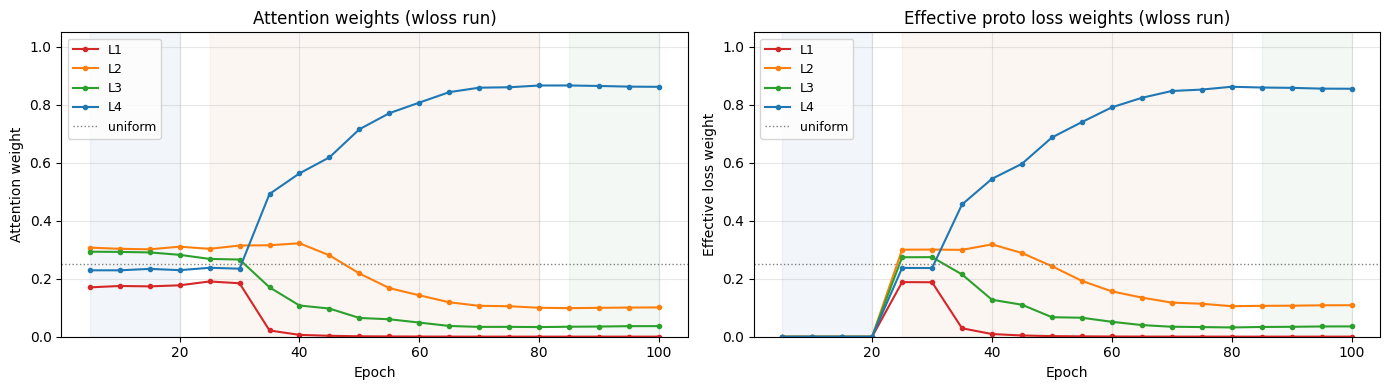

Final epoch 100:
  Attention weights    : L1=0.0003  L2=0.1011  L3=0.0366  L4=0.8620
  Eff. loss weights    : L1=0.0003  L2=0.1087  L3=0.0356  L4=0.8554


In [13]:
# Plot w_Ll (attention) vs eff_w_Ll (loss weight) side-by-side for wloss run
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ph_cols = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}

for ax, col_prefix, ylabel, title in [
    (axes[0], "w_L", "Attention weight", "Attention weights (wloss run)"),
    (
        axes[1],
        "eff_w_L",
        "Effective loss weight",
        "Effective proto loss weights (wloss run)",
    ),
]:
    for ph, color in ph_cols.items():
        mask = attn_wloss_log["phase"] == ph
        if mask.any():
            ax.axvspan(
                attn_wloss_log.loc[mask, "epoch"].min(),
                attn_wloss_log.loc[mask, "epoch"].max(),
                alpha=0.07,
                color=color,
            )
    for i, l in enumerate(PROTO_LEVELS):
        col = f"{col_prefix}{l}"
        if col in attn_wloss_log.columns:
            ax.plot(
                attn_wloss_log["epoch"],
                attn_wloss_log[col],
                "o-",
                ms=3,
                lw=1.5,
                color=LEVEL_COLORS[i],
                label=f"L{l}",
            )
    ax.axhline(0.25, color="gray", ls=":", lw=1, label="uniform")
    ax.set(title=title, xlabel="Epoch", ylabel=ylabel, ylim=(0, 1.05))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT}/effective_loss_weights_wloss.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabulate final epoch
r = attn_wloss_log.iloc[-1]
print(f"Final epoch {int(r['epoch'])}:")
print(
    f"  Attention weights    : "
    + "  ".join(f"L{l}={r[f'w_L{l}']:.4f}" for l in PROTO_LEVELS)
)
print(
    f"  Eff. loss weights    : "
    + "  ".join(f"L{l}={r[f'eff_w_L{l}']:.4f}" for l in PROTO_LEVELS)
)

## 10. Heatmap Comparison: M4-attn-noent vs M4-attn-wloss vs M2

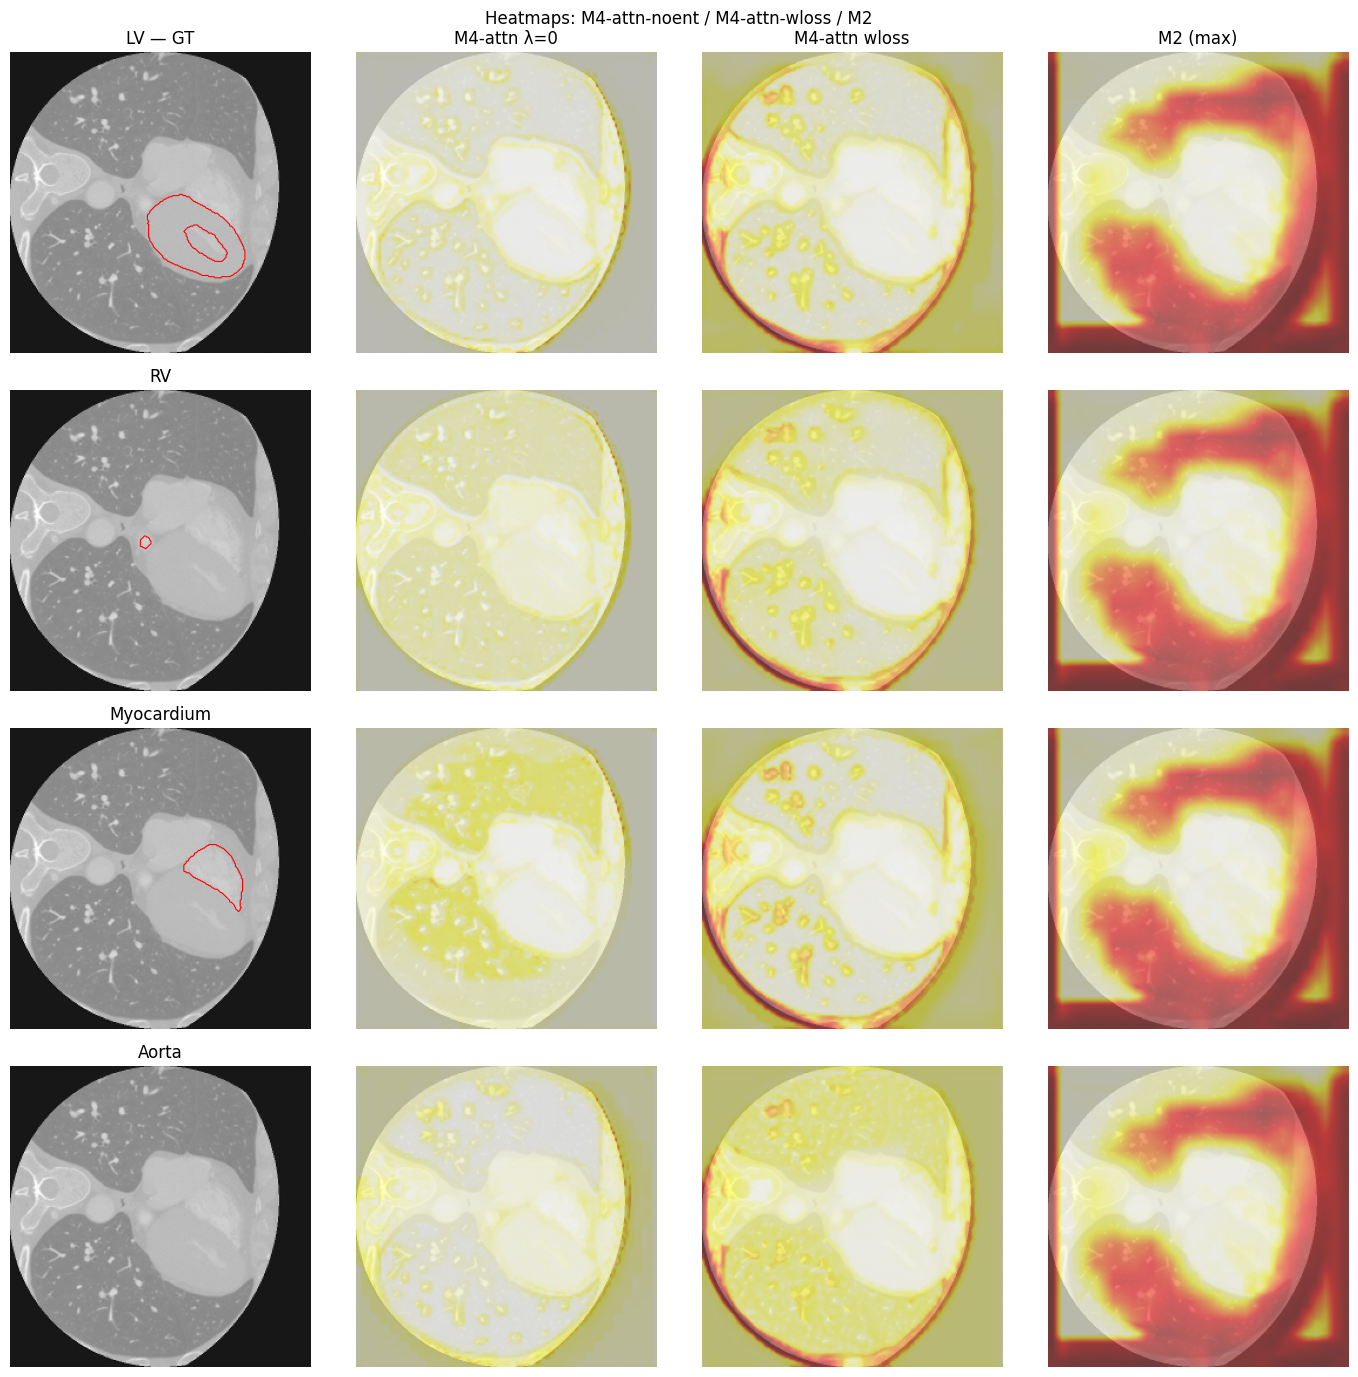

In [14]:
@torch.no_grad()
def get_class_heatmap(model, img):
    """Returns (K, H, W) heatmap — max over levels and prototypes."""
    _, hm = model(img)
    level_maps = []
    for l, A in hm.items():
        A_max = A[0].max(dim=1).values  # (K, H_l, W_l)
        A_up = F.interpolate(
            A_max.unsqueeze(0), size=(256, 256), mode="bilinear", align_corners=False
        )[0]
        level_maps.append(A_up)
    return torch.stack(level_maps).max(dim=0).values.cpu()  # (K, 256, 256)


# Find a rich test slice (≥5 foreground classes present)
test_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "test", augment=False, preload=True)
best_slice = next(
    idx
    for idx in range(len(test_ds))
    if sum((test_ds[idx]["label"] == c).any().item() for c in range(1, NUM_CLASSES))
    >= 5
)
s = test_ds[best_slice]
img = s["image"].unsqueeze(0).to(DEVICE)
lbl = s["label"]

hm_noent = get_class_heatmap(m4_noent, img)
hm_wloss = get_class_heatmap(m4_wloss, img)
hm_m2 = get_class_heatmap(m2, img)
img_np = img[0, 0].cpu().numpy()

SHOW_CLASSES = [1, 2, 5, 6]  # LV, RV, Myo, Aorta
fig, axes = plt.subplots(len(SHOW_CLASSES), 4, figsize=(14, 3.5 * len(SHOW_CLASSES)))

for row, c in enumerate(SHOW_CLASSES):
    axes[row, 0].imshow(img_np, cmap="gray")
    axes[row, 0].contour((lbl == c).numpy(), colors="red", linewidths=0.8)
    axes[row, 0].set_title(f"{LABEL_NAMES[c]} — GT" if row == 0 else LABEL_NAMES[c])
    axes[row, 0].axis("off")
    for col, (hm, title) in enumerate(
        [(hm_noent, "M4-attn λ=0"), (hm_wloss, "M4-attn wloss"), (hm_m2, "M2 (max)")], 1
    ):
        axes[row, col].imshow(img_np, cmap="gray", alpha=0.6)
        axes[row, col].imshow(hm[c].numpy(), cmap="hot", alpha=0.5, vmin=0, vmax=1)
        if row == 0:
            axes[row, col].set_title(title)
        axes[row, col].axis("off")

plt.suptitle("Heatmaps: M4-attn-noent / M4-attn-wloss / M2", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT}/heatmap_comparison_wloss.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. RQ6 Answer

In [15]:
print("=" * 65)
print("RQ6: Does attention-weighted prototype loss eliminate gradient")
print("     contamination and recover L4 prototype quality?")
print("=" * 65)

r_final = attn_wloss_log.iloc[-1]
w_L1 = r_final["w_L1"]
w_L2 = r_final["w_L2"]
w_L4 = r_final["w_L4"]

print(f"\n— Segmentation —")
print(f"  3D Dice wloss : {dice_m4_wloss:.4f}")
print(f"  3D Dice noent : {dice_m4_noent:.4f}  Δ={dice_m4_wloss - dice_m4_noent:+.4f}")
print(
    f"  Criterion     : ≥ {dice_m4_noent:.4f}  "
    + ("✅" if dice_m4_wloss >= dice_m4_noent else "❌")
)

print(f"\n— Prototype Quality (L4) —")
print(
    f"  Purity  noent={noent_pur:.3f}  wloss={pur_l4_wloss:.3f}  "
    + f"Δ={pur_l4_wloss - noent_pur:+.3f}  "
    + ("✅ > 0.70" if pur_l4_wloss > 0.70 else f"❌ target 0.70")
)
print(
    f"  AP      noent={noent_ap:.3f}  wloss={ap_l4_wloss:.3f}  "
    + f"Δ={ap_l4_wloss - noent_ap:+.3f}  "
    + ("✅ > 0.15" if ap_l4_wloss > 0.15 else f"❌ target 0.15")
)
print(
    f"  Compact noent={noent_comp:.3f}  wloss={comp_l4_wloss:.3f}  "
    + f"Δ={comp_l4_wloss - noent_comp:+.3f}"
)

print(f"\n— Attention Hierarchy —")
print(
    f"  Final weights: L1={w_L1:.4f}  L2={w_L2:.4f}  L3={r_final['w_L3']:.4f}  L4={w_L4:.4f}"
)
print(f"  w_L4 > 0.5 : " + ("✅" if w_L4 > 0.5 else "❌") + f"  ({w_L4:.4f})")
print(
    f"  w_L1+L2 < 0.10 : "
    + ("✅" if w_L1 + w_L2 < 0.10 else "❌")
    + f"  ({w_L1 + w_L2:.4f})"
)
print(
    f"  Note: L2 did NOT collapse to 0 (unlike noent). "
    f"Feedback loop stabilised L2 at w≈{w_L2:.2f}."
)

# Overall verdict
purity_pass = pur_l4_wloss > 0.70
ap_pass = ap_l4_wloss > 0.15
dice_pass = dice_m4_wloss >= dice_m4_noent
hier_pass = w_L4 > 0.5 and w_L1 + w_L2 < 0.10
criteria_met = sum([purity_pass, ap_pass, dice_pass, hier_pass])

print(f"\n{'=' * 65}")
print(f"Criteria met: {criteria_met}/4")
if criteria_met == 4:
    print("✅ RQ6: YES — weighted loss fully recovered L4 quality.")
elif criteria_met >= 2:
    print("⚠️  RQ6: PARTIAL — some quality recovered, not all criteria met.")
else:
    print("❌ RQ6: NO — weighted loss did not recover L4 quality.")

RQ6: Does attention-weighted prototype loss eliminate gradient
     contamination and recover L4 prototype quality?

— Segmentation —
  3D Dice wloss : 0.8475
  3D Dice noent : 0.8416  Δ=+0.0059
  Criterion     : ≥ 0.8416  ✅

— Prototype Quality (L4) —
  Purity  noent=0.537  wloss=0.697  Δ=+0.160  ❌ target 0.70
  AP      noent=0.085  wloss=0.195  Δ=+0.110  ✅ > 0.15
  Compact noent=0.494  wloss=0.365  Δ=-0.129

— Attention Hierarchy —
  Final weights: L1=0.0003  L2=0.1011  L3=0.0366  L4=0.8620
  w_L4 > 0.5 : ✅  (0.8620)
  w_L1+L2 < 0.10 : ❌  (0.1014)
  Note: L2 did NOT collapse to 0 (unlike noent). Feedback loop stabilised L2 at w≈0.10.

Criteria met: 2/4
⚠️  RQ6: PARTIAL — some quality recovered, not all criteria met.
